In [2]:
import quante as qt
qt.basicfun.clear_numba_cache()

In [2]:
import quante as qt

a, b = 1, [1, 2, 3]
show(a, b)

a: 1; b: [1, 2, 3]


## 保存日志

通过在项目最开始运行：

In [4]:
qt.basicfun.set_logging(savelog=False, logtime=True)

可以将所有 `qt.basicfun.println`/`show` 的输出保存到 log 文件中，同时记录时间。

报错信息同样会记录到 log 文件中

In [5]:
show("hello world")

2025-06-23 18:03:51,352: hello world


In [6]:
qt.basicfun.set_logging(savelog=False, logtime=False)
show("hello world")

hello world


In [7]:
a = [1,2,3]
b = [4,5,6]
show(a, b)

a: [1, 2, 3]; b: [4, 5, 6]


In [8]:
a = [1,2,3]
b = 1
show(
    a,
    b
)

a: [1, 2, 3]; b: 1


In [9]:
a, b = [1,2,3], 1
show()

a: [1, 2, 3]; b: 1


In [10]:
qt.basicfun.set_show(arg_name=False)
a = [1,2,3]
b = 1
show(
    a,
    b,
)

[1, 2, 3]
1


## 数据保存

通过 `save_hdf5` 和 `load_hdf5` 可以保存和加载数据。

In [ ]:
import numpy as np
qt.basicfun.save_hdf5(
    "data.h5", 
    {
        "a": np.random.randn(2,2),
        "b": [1,2,3],
        "c": {"d": 1, "e": 2}
    },
)

('data.h5', '/')

In [4]:
a, b, c = qt.basicfun.load_hdf5(
    "data.h5", 
    ['a', 'b', 'c'],
)
show(a,b,c)

a: [[-0.19082216 -0.42988379]
    [ 0.34401432 -0.07741815]]
b: [1, 2, 3]
c: {'d': np.int64(1), 'e': np.int64(2)}


选项 `group` 可以控制数据保存的层级。

load 时不指定数据时会加载所有数据。

In [3]:
qt.basicfun.load_hdf5("data.h5")

{'a': array([[-0.19082216, -0.42988379],
        [ 0.34401432, -0.07741815]]),
 'b': [1, 2, 3],
 'c': {'d': np.int64(1), 'e': np.int64(2)}}

`iload` 可以统一保存和加载数据的格式

In [5]:
import numpy as np
a = np.random.randn(10,10)
b = [1,2,3]
a, b = qt.basicfun.isave("data.h5")

In [6]:
a, b = qt.basicfun.iload("data.h5") 

## 画图预设

### 查看变量占用的内存

python 自带的内存大小函数只会显示指针占用内存

In [17]:
a = [np.random.rand(1000,1000)]
import sys
sys.getsizeof(a)

64

使用 test_memory 可以正确显示内存占用大小

In [18]:
qt.basicfun.print_memory_usage(a)

7.63 MB


matplotlib 默认的画图风格为：

Text(0, 0.5, '$\\sin x$')

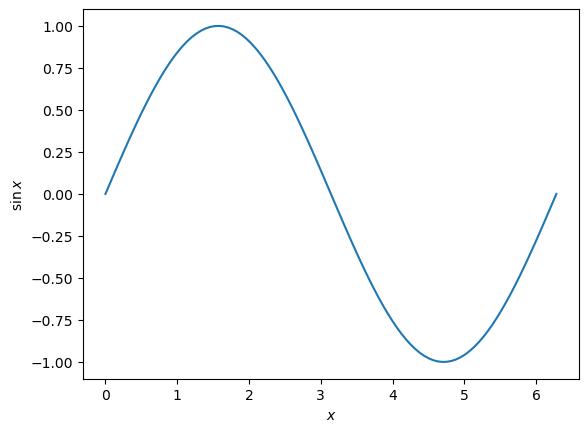

In [19]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

plt.plot(x, y)
plt.xlabel(r'$x$')
plt.ylabel(r'$\sin x$')

通过 `plt_style_use` 可以改变风格：

Text(0, 0.5, '$\\sin x$')

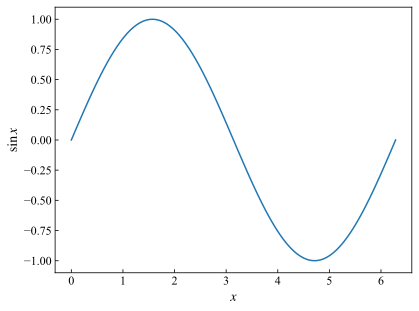

In [20]:
import matplotlib.pyplot as plt
import numpy as np
qt.basicfun.plt_style_use()

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

plt.plot(x, y)
plt.xlabel(r'$x$')
plt.ylabel(r'$\sin x$')

Text(0, 0.5, '$\\sin x$')

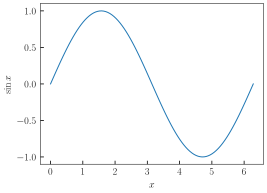

In [21]:
import matplotlib.pyplot as plt
import numpy as np
qt.basicfun.plt_style_use('science')

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

plt.plot(x, y)
plt.xlabel(r'$x$')
plt.ylabel(r'$\sin x$')

### 查看变量占用的内存

python 自带的内存大小函数只会显示指针占用内存

In [22]:
a = [np.random.rand(1000,1000)]
import sys
sys.getsizeof(a)

64

使用 test_memory 可以正确显示内存占用大小

In [23]:
qt.basicfun.print_memory_usage(a)

7.63 MB


## 代码调试工具

### 显示代码运行运行的时间

In [24]:
import numpy as np

def singlestep(a, i, j):
    a = np.sin(a)
    return a + i + j

def myfun(dim):
    mat = np.random.randn(dim,dim)
    for i in range(dim):
        for j in range(dim):
            mat[i,j] = singlestep(mat[i,j], i, j)
    return mat

with Timer(myfun, singlestep):
    myfun(100)

Timer unit: 0.001 s

Total time: 0.0100443 s
File: C:\Users\hzhu\AppData\Local\Temp\ipykernel_14512\2100961480.py
Function: singlestep at line 3

Line #      Hits         Time  Per Hit   % Time  Line Contents
     3                                           def singlestep(a, i, j):
     4     10000          7.2      0.0     71.2      a = np.sin(a)
     5     10000          2.9      0.0     28.8      return a + i + j

Total time: 0.0225726 s
File: C:\Users\hzhu\AppData\Local\Temp\ipykernel_14512\2100961480.py
Function: myfun at line 7

Line #      Hits         Time  Per Hit   % Time  Line Contents
     7                                           def myfun(dim):
     8         1          0.1      0.1      0.6      mat = np.random.randn(dim,dim)
     9       101          0.0      0.0      0.1      for i in range(dim):
    10     10100          1.8      0.0      7.9          for j in range(dim):
    11     10000         20.6      0.0     91.4              mat[i,j] = singlestep(mat[i,j], i,

显示了每一行运行需要的时间

如果是 py 文件中，可以使用 profile 装饰器

```python
@bf.profile()
def singlestep(a, i, j):
    a = np.sin(a)
    return a + i + j

@bf.profile()
def myfun(dim):
    mat = np.random.randn(dim,dim)
    for i in range(dim):
        for j in range(dim):
            mat[i,j] = singlestep(mat[i,j], i, j)
    return mat

myfun(100)
```

## Dynamic Plot

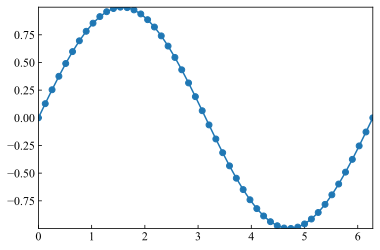

In [25]:
import quante as qt
import numpy as np
import matplotlib.pyplot as plt

qt.basicfun.plt_style_use()
xs = np.linspace(0, 2*np.pi, 50)
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
res = qt.basicfun.DynamicPlot(xs, ax, 'o-', label='sin(x)')
for x in xs:
    res.append(np.sin(x))

array([[ 1.        ,  0.99798668,  0.99195481,  0.9819287 ,  0.9679487 ,  0.95007112,  0.92836793,  0.90292654,  0.87384938,  0.84125353,  0.80527026,  0.76604444,  0.72373404,  0.67850941,  0.63055267,  0.58005691,  0.52722547,  0.47227107,  0.41541501,  0.35688622,  0.29692038,  0.23575894,  0.17364818,  0.1108382 ,  0.04758192, -0.01586596, -0.07924996, -0.14231484, -0.20480667, -0.26647381, -0.32706796, -0.38634513, -0.44406661, -0.5       , -0.55392006, -0.60560969, -0.65486073, -0.70147489, -0.74526445, -0.78605309, -0.82367658, -0.85798341, -0.88883545, -0.91610846, -0.93969262, -0.95949297, -0.97542979, -0.98743889, -0.99547192, -0.99949654, -0.99949654, -0.99547192, -0.98743889, -0.97542979, -0.95949297, -0.93969262, -0.91610846, -0.88883545, -0.85798341, -0.82367658, -0.78605309, -0.74526445, -0.70147489, -0.65486073, -0.60560969, -0.55392006, -0.5       , -0.44406661, -0.38634513, -0.32706796, -0.26647381, -0.20480667, -0.14231484, -0.07924996, -0.01586596,  0.04758192,  0.1

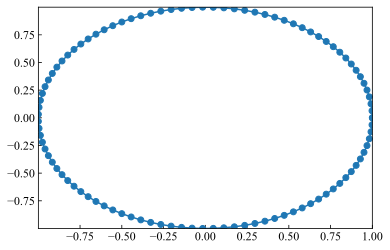

In [26]:
import quante as qt
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(0, 2*np.pi, 100)
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
dp = qt.basicfun.DynamicPlot(xs, ax, 'o-', label='sin(x)')
for x in xs:
    dp.append((np.cos(x), np.sin(x)))
dp

array([[ 0.        ,  0.64278761,  0.98480775,  0.8660254 ,  0.34202014, -0.34202014, -0.8660254 , -0.98480775, -0.64278761, -0.        ],
       [ 0.64278761,  0.98480775,  0.8660254 ,  0.34202014, -0.34202014, -0.8660254 , -0.98480775, -0.64278761, -0.        ,  0.64278761],
       [ 0.98480775,  0.8660254 ,  0.34202014, -0.34202014, -0.8660254 , -0.98480775, -0.64278761, -0.        ,  0.64278761,  0.98480775],
       [ 0.8660254 ,  0.34202014, -0.34202014, -0.8660254 , -0.98480775, -0.64278761, -0.        ,  0.64278761,  0.98480775,  0.8660254 ],
       [ 0.34202014, -0.34202014, -0.8660254 , -0.98480775, -0.64278761, -0.        ,  0.64278761,  0.98480775,  0.8660254 ,  0.34202014],
       [-0.34202014, -0.8660254 , -0.98480775, -0.64278761, -0.        ,  0.64278761,  0.98480775,  0.8660254 ,  0.34202014, -0.34202014],
       [-0.8660254 , -0.98480775, -0.64278761, -0.        ,  0.64278761,  0.98480775,  0.8660254 ,  0.34202014, -0.34202014, -0.8660254 ],
       [-0.98480775, -0.642

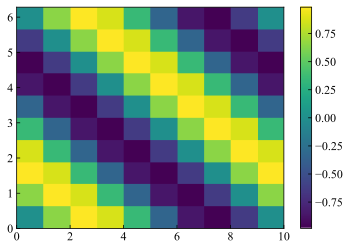

In [27]:
import quante as qt
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(0, 2*np.pi, 10)
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
dp = qt.basicfun.DynamicPlot(xs, ax).set(legend=True)
for x in xs:
    dp.append([np.sin(x + phi) for phi in np.linspace(0, 2*np.pi, 10)])
dp

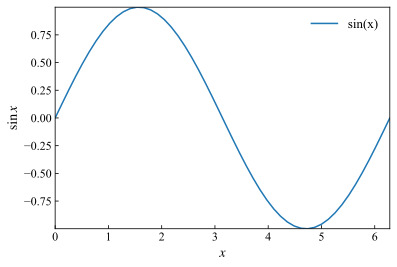

In [28]:
import quante as qt
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(0, 2*np.pi, 50)
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\sin x$')
res = qt.basicfun.DynamicPlot(xs, ax, label='sin(x)')
res.set(legend=True)
for x in xs:
    res.append(np.sin(x))

In [23]:
import os
# delete data.h5
if os.path.exists("data.h5"):
    os.remove("data.h5")